# AOC 期末專題 ── 第 2 組
# LayerNorm → RMSNorm 替換實驗：ViT-Small/16 on CIFAR-10

> **目的**：回應規格書 v3.1 第 6.6 節需求  
> 驗證「以 RMSNorm 取代 LayerNorm 後，CIFAR-10 Top-1 精度損失 < 0.2 pp」  
> 並提供每一層激活分佈視覺化，確認訓練不崩潰

---

## 為什麼要換掉 LayerNorm？

| 比較項目 | LayerNorm | RMSNorm |
|---------|-----------|----------|
| 公式 | $y = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} \cdot \gamma + \beta$ | $y = \frac{x}{\text{RMS}(x)} \cdot \gamma$ |
| 需要統計量 | 均值 $\mu$＋變異數 $\sigma^2$ | 只需均方根 $\text{RMS}$ |
| 需要偏置 $\beta$ | ✅ 是 | ❌ 否（省參數）|
| 硬體遍歷次數 | **2 次**（先算 $\mu$，再算 $\sigma$）| **1 次** |
| 適合串流硬體 | ❌ 不友好 | ✅ 友好 |
| 代表模型 | BERT, ViT | LLaMA, T5, GPT-NeoX |

**FPGA 關鍵優勢**：RMSNorm 只需一次遍歷累加 $\sum x_i^2$，  
對 14×14 收縮陣列的串流 PPU 設計非常友好（見規格書 6.6 節）

---

## 本 Notebook 流程

```
Step 1  安裝依賴 + 全域設定
Step 2  資料集（CIFAR-10 → 224×224）
Step 3  理解 LayerNorm 原始實作（視覺化）
Step 4  實作 RMSNorm 模組（含 FPGA 對應說明）
Step 5  模型手術：替換 ViT-Small 中所有 LayerNorm
Step 6  視覺化每一層 Norm 的位置與參數量
Step 7  前向傳播健康檢查（激活分佈不爆炸/消失）
Step 8  Fine-tune 訓練（LayerNorm vs RMSNorm，相同條件）
Step 9  精度對比 + 結論
```

In [13]:
# ═══════════════════════════════════════════════════════════════
# Step 1A：安裝依賴套件
# ═══════════════════════════════════════════════════════════════
# timm  = PyTorch Image Models（提供預訓練 ViT）
# einops = 張量維度操作工具（視覺化時用到）

import subprocess, sys

for pkg in ["timm>=1.0", "einops"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

print("依賴安裝完成")

依賴安裝完成


In [14]:
# ═══════════════════════════════════════════════════════════════
# Step 1B：匯入所有函式庫
# ═══════════════════════════════════════════════════════════════

import os, time, copy, warnings
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import timm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from collections import OrderedDict

warnings.filterwarnings("ignore")

# ─── 重現性種子 ───────────────────────────────────────────────
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'sans-serif']
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"PyTorch  : {torch.__version__}")
print(f"timm     : {timm.__version__}")
print(f"CUDA 可用 : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

PyTorch  : 2.9.1+cu128
timm     : 1.0.26
CUDA 可用 : True
GPU      : NVIDIA GeForce RTX 5060


In [15]:
# ═══════════════════════════════════════════════════════════════
# Step 1C：全域超參數（集中管理，方便修改）
# ═══════════════════════════════════════════════════════════════

DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_DIR     = "./ckpt_rmsnorm"        # 存放本實驗 checkpoint 的目錄
os.makedirs(CKPT_DIR, exist_ok=True)

IMG_SIZE     = 224                     # ViT-Small 預訓練輸入大小
BATCH_TRAIN  = 64                      # 訓練 batch（可依 GPU VRAM 調整）
BATCH_TEST   = 128                     # 評估 batch

# ─── Fine-tune 超參數（與規格書 Phase 0 保持一致，確保公平比較）────
EPOCHS       = 5                       # 規格書指定 5 epochs
BASE_LR      = 1e-4                    # 最高層學習率
LAYER_DECAY  = 0.75                    # 每往輸入方向一層乘 0.75
WEIGHT_DECAY = 0.05
LABEL_SMOOTH = 0.1

# ImageNet 標準化參數（預訓練模型期望的輸入分佈）
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

CIFAR10_CLASSES = ["airplane","automobile","bird","cat","deer",
                   "dog","frog","horse","ship","truck"]

print(f"執行裝置 : {DEVICE}")
print(f"訓練 Epoch : {EPOCHS}")
print(f"Checkpoint 目錄 : {CKPT_DIR}")

執行裝置 : cuda
訓練 Epoch : 5
Checkpoint 目錄 : ./ckpt_rmsnorm


In [16]:
# ═══════════════════════════════════════════════════════════════
# Step 2：CIFAR-10 資料集
# ═══════════════════════════════════════════════════════════════
# CIFAR-10 原始解析度 32×32，ViT 需要 224×224
# 使用 Bicubic 插值上採樣（與規格書一致）
#
# 訓練集增強：RandomHorizontalFlip + ColorJitter（防止過擬合）
# 測試集：只做 Resize + CenterCrop（固定，確保評估穩定）

transform_train = transforms.Compose([
    # 32→256: Bicubic 放大（保留高頻細節優於 Bilinear）
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SIZE),        # 256→224, 裁去邊緣
    transforms.RandomHorizontalFlip(p=0.5), # 資料增強：水平翻轉
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),  # 色彩抖動
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),  # 對齊預訓練分佈
])

transform_test = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.CIFAR10("./data", train=True,  download=True, transform=transform_train)
test_dataset  = datasets.CIFAR10("./data", train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_TRAIN,
                          shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_TEST,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"訓練集：{len(train_dataset):,} 筆  |  測試集：{len(test_dataset):,} 筆")
print(f"訓練 batch 數：{len(train_loader)}  |  測試 batch 數：{len(test_loader)}")

訓練集：50,000 筆  |  測試集：10,000 筆
訓練 batch 數：782  |  測試 batch 數：79


---
## Step 3：理解 LayerNorm（拆解原始公式）

在開始替換之前，先視覺化 LayerNorm 和 RMSNorm 的差異，建立直覺。

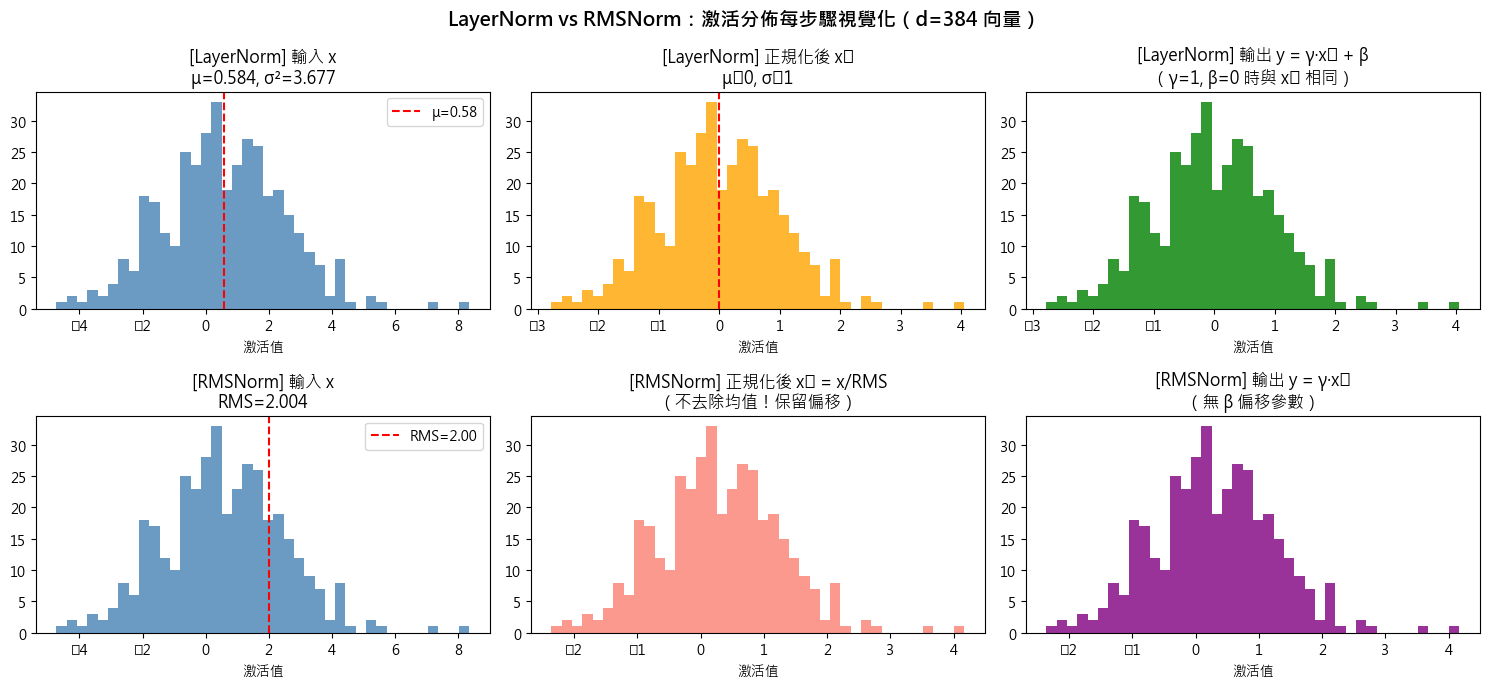


════════════════════════════════════════════════════════════
LayerNorm 輸出：mean=-0.0000, std=1.0000
RMSNorm  輸出：mean=0.2911, std=0.9567

注意：RMSNorm 不保證均值=0（沒有減去 μ）
      但在 ViT 的 Transformer block 中，Residual Connection 會補償這個差異


In [17]:
# ═══════════════════════════════════════════════════════════════
# Step 3A：手動實作 LayerNorm，逐步視覺化每個計算步驟
# ═══════════════════════════════════════════════════════════════
#
# LayerNorm 公式（對一個向量 x，長度 d）：
#   μ   = mean(x)                          ← 需要第 1 次遍歷
#   σ²  = mean((x - μ)²)                   ← 需要第 2 次遍歷（或存整個 x）
#   y   = (x - μ) / sqrt(σ² + ε) * γ + β  ← 縮放+偏移
#
# 問題：硬體串流時，第 1 次 pass 完才能知道 μ，
#       必須把整個向量存進 SRAM，才能做第 2 次 pass。
#       對 d=384 的向量 = 384×2B = 768 Bytes 的暫存需求。

def layernorm_manual(x, gamma, beta, eps=1e-6):
    """
    手動實作 LayerNorm（等價於 nn.LayerNorm）
    x     : (d,) 向量
    gamma : (d,) 可學習縮放
    beta  : (d,) 可學習偏移
    回傳每個中間步驟供視覺化
    """
    mu    = x.mean()                          # 步驟①：計算均值（1st pass）
    x_c   = x - mu                            # 步驟②：中心化
    var   = (x_c ** 2).mean()                 # 步驟③：計算變異數（2nd pass）
    x_hat = x_c / (var + eps).sqrt()          # 步驟④：正規化
    y     = gamma * x_hat + beta              # 步驟⑤：仿射變換
    return y, {"mu": mu.item(), "var": var.item(),
               "x_hat": x_hat.numpy(), "y": y.numpy()}


def rmsnorm_manual(x, gamma, eps=1e-6):
    """
    手動實作 RMSNorm
    x     : (d,) 向量
    gamma : (d,) 可學習縮放（無 beta！）
    回傳每個中間步驟供視覺化

    硬體優勢：
      rms = sqrt(mean(x²))  ← 只需累加 x²，不需先知道均值
      → 串流一次遍歷即可完成！
    """
    rms   = (x ** 2).mean().sqrt()            # 步驟①：計算 RMS（1 pass 即可）
    x_hat = x / (rms + eps)                   # 步驟②：正規化
    y     = gamma * x_hat                     # 步驟③：縮放（無偏移 beta）
    return y, {"rms": rms.item(),
               "x_hat": x_hat.numpy(), "y": y.numpy()}


# ─── 製造一個模擬 ViT 激活的測試向量（d=384，模擬 Block 輸出）────────
torch.manual_seed(0)
d_test   = 384
x_test   = torch.randn(d_test) * 2.0 + 0.5    # 均值≠0，標準差≠1（刻意不規則）
gamma_ln = torch.ones(d_test)                  # 初始化為 1（等同 identity 縮放）
beta_ln  = torch.zeros(d_test)                 # 初始化為 0
gamma_rms= torch.ones(d_test)

y_ln,  stats_ln  = layernorm_manual(x_test, gamma_ln, beta_ln)
y_rms, stats_rms = rmsnorm_manual(x_test, gamma_rms)

# ─── 視覺化：並排比較兩種正規化的效果 ────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle("LayerNorm vs RMSNorm：激活分佈每步驟視覺化（d=384 向量）",
             fontsize=14, fontweight="bold")

# ── 上排：LayerNorm ──
axes[0,0].hist(x_test.numpy(), bins=40, color="steelblue", alpha=0.8)
axes[0,0].set_title(f"[LayerNorm] 輸入 x\nμ={stats_ln['mu']:.3f}, σ²={stats_ln['var']:.3f}")
axes[0,0].axvline(stats_ln['mu'], color='red', linestyle='--', label=f"μ={stats_ln['mu']:.2f}")
axes[0,0].legend(); axes[0,0].set_xlabel("激活值")

axes[0,1].hist(stats_ln['x_hat'], bins=40, color="orange", alpha=0.8)
axes[0,1].set_title(f"[LayerNorm] 正規化後 x̂\nμ≈0, σ≈1")
axes[0,1].axvline(0, color='red', linestyle='--')
axes[0,1].set_xlabel("激活值")

axes[0,2].hist(stats_ln['y'], bins=40, color="green", alpha=0.8)
axes[0,2].set_title("[LayerNorm] 輸出 y = γ·x̂ + β\n（γ=1, β=0 時與 x̂ 相同）")
axes[0,2].set_xlabel("激活值")

# ── 下排：RMSNorm ──
axes[1,0].hist(x_test.numpy(), bins=40, color="steelblue", alpha=0.8)
axes[1,0].set_title(f"[RMSNorm] 輸入 x\nRMS={stats_rms['rms']:.3f}")
axes[1,0].axvline(stats_rms['rms'], color='red', linestyle='--',
                  label=f"RMS={stats_rms['rms']:.2f}")
axes[1,0].legend(); axes[1,0].set_xlabel("激活值")

axes[1,1].hist(stats_rms['x_hat'], bins=40, color="salmon", alpha=0.8)
axes[1,1].set_title(f"[RMSNorm] 正規化後 x̂ = x/RMS\n（不去除均值！保留偏移）")
axes[1,1].set_xlabel("激活值")

axes[1,2].hist(stats_rms['y'], bins=40, color="purple", alpha=0.8)
axes[1,2].set_title("[RMSNorm] 輸出 y = γ·x̂\n（無 β 偏移參數）")
axes[1,2].set_xlabel("激活值")

plt.tight_layout()
plt.savefig("layernorm_vs_rmsnorm_distribution.png", dpi=120)
plt.show()
print()
print("═"*60)
print(f"LayerNorm 輸出：mean={stats_ln['y'].mean():.4f}, std={stats_ln['y'].std():.4f}")
print(f"RMSNorm  輸出：mean={stats_rms['y'].mean():.4f}, std={stats_rms['y'].std():.4f}")
print()
print("注意：RMSNorm 不保證均值=0（沒有減去 μ）")
print("      但在 ViT 的 Transformer block 中，Residual Connection 會補償這個差異")

---
## Step 4：實作 RMSNorm PyTorch 模組

這個模組將直接替換 timm ViT-Small 中所有的 `nn.LayerNorm`。

In [18]:
# ═══════════════════════════════════════════════════════════════
# Step 4：RMSNorm 模組實作
# ═══════════════════════════════════════════════════════════════
#
# 數學定義：
#   RMS(x)  = sqrt( (1/d) * Σ xᵢ² )     ← 均方根（Root Mean Square）
#   y       = (x / RMS(x)) * γ
#
# 與 nn.LayerNorm 接口對齊：
#   nn.LayerNorm(normalized_shape, eps, elementwise_affine)
#   RMSNorm  (normalized_shape, eps, elementwise_affine)
#   → 外部呼叫方式完全相同，可直接 swap！
#
# FPGA 硬體對應（規格書 6.6 節）：
#   Pass 1（串流）：rms_acc += x[i]² → 累加到 INT32
#   inv_rms = lut_inv_sqrt[rms_acc >> shift]  ← 1-cycle LUT
#   Pass 2（串流）：y[i] = x[i] * inv_rms * gamma[i]
#   → 比 LayerNorm 少一次完整遍歷，省 SRAM 暫存

class RMSNorm(nn.Module):
    """
    Root Mean Square Layer Normalization

    參考論文：
      Zhang & Sennrich (2019) "Root Mean Square Layer Normalization"
      https://arxiv.org/abs/1910.07467

    Args:
        normalized_shape : int 或 tuple，正規化的維度（對 ViT 就是 d_model）
        eps              : 數值穩定性常數（避免除以 0）
        elementwise_affine : 是否學習縮放 γ（建議 True，與 LayerNorm 一致）
    """

    def __init__(self, normalized_shape, eps=1e-6, elementwise_affine=True):
        super().__init__()

        # normalized_shape 可以是 int（常見）或 tuple（LayerNorm 相容）
        if isinstance(normalized_shape, int):
            self.normalized_shape = (normalized_shape,)
        else:
            self.normalized_shape = tuple(normalized_shape)

        self.eps = eps
        self.elementwise_affine = elementwise_affine

        # γ（可學習縮放）：初始化為全 1
        # 注意：RMSNorm 沒有 β（偏移）！這樣省了 d 個參數
        if elementwise_affine:
            self.weight = nn.Parameter(torch.ones(self.normalized_shape))
        else:
            self.register_parameter('weight', None)

        # RMSNorm 沒有 bias，但宣告為 None 以相容 LayerNorm 的屬性存取
        self.bias = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        前向傳播
        x shape: (..., d)  ← 最後一個維度是 d_model，其他維度任意

        計算流程（對應 FPGA Pass 1 + Pass 2）：
          1. 計算 x 最後維度的均方：x_sq_mean = mean(x²)
          2. 計算 inv_rms = 1 / sqrt(x_sq_mean + eps)
          3. 正規化：x_norm = x * inv_rms
          4. 縮放：y = x_norm * γ
        """
        # keepdim=True 保持維度，讓 broadcasting 正確作用
        # x.float() 用 FP32 計算（防止 FP16 溢位），結果轉回原型別
        dtype_orig = x.dtype
        x_fp32 = x.float()

        # Step①：計算每個 token 向量的均方（沿最後一個維度）
        # x_sq_mean shape: (..., 1)
        x_sq_mean = x_fp32.pow(2).mean(dim=-1, keepdim=True)

        # Step②：計算 1 / RMS（rsqrt = reciprocal square root，單一運算，效率高）
        inv_rms = torch.rsqrt(x_sq_mean + self.eps)

        # Step③：正規化（每個元素乘以 inv_rms）
        x_norm = x_fp32 * inv_rms

        # Step④：可學習縮放 γ（若啟用）
        if self.weight is not None:
            x_norm = x_norm * self.weight.float()

        # 轉回原始資料型別（支援 FP16/BF16 訓練）
        return x_norm.to(dtype_orig)

    def extra_repr(self) -> str:
        """print(model) 時顯示的額外資訊"""
        return (f"normalized_shape={self.normalized_shape}, "
                f"eps={self.eps}, "
                f"elementwise_affine={self.elementwise_affine}")


# ─── 單元測試：確認 RMSNorm 與 nn.LayerNorm 接口相容 ────────────────
print("=== RMSNorm 單元測試 ===")

x_check = torch.randn(2, 197, 384)     # batch=2, tokens=197, d=384（ViT-Small 真實尺寸）

ln_ref  = nn.LayerNorm(384, eps=1e-6)  # PyTorch 官方 LayerNorm（參考）
rms_mod = RMSNorm(384, eps=1e-6)       # 我們的 RMSNorm

y_ln_ref  = ln_ref(x_check)
y_rms_mod = rms_mod(x_check)

print(f"輸入  shape: {x_check.shape}")
print(f"LN  輸出 shape: {y_ln_ref.shape}   mean={y_ln_ref.mean():.4f}")
print(f"RMS 輸出 shape: {y_rms_mod.shape}  mean={y_rms_mod.mean():.4f}")
print(f"\n輸出相近（初始化時γ=1,β=0 所以不完全相同）：")
print(f"  最大差異 = {(y_ln_ref - y_rms_mod).abs().max():.4f}")
print(f"  平均差異 = {(y_ln_ref - y_rms_mod).abs().mean():.4f}")
print()
print("✅ RMSNorm 接口正確（輸入/輸出 shape 相同）")
print("⚠  注意：LN 和 RMS 輸出不相同是正常的（計算方法不同）")
print("   訓練後 γ 會調整到適合的分佈")

=== RMSNorm 單元測試 ===
輸入  shape: torch.Size([2, 197, 384])
LN  輸出 shape: torch.Size([2, 197, 384])   mean=0.0000
RMS 輸出 shape: torch.Size([2, 197, 384])  mean=-0.0019

輸出相近（初始化時γ=1,β=0 所以不完全相同）：
  最大差異 = 0.1798
  平均差異 = 0.0395

✅ RMSNorm 接口正確（輸入/輸出 shape 相同）
⚠  注意：LN 和 RMS 輸出不相同是正常的（計算方法不同）
   訓練後 γ 會調整到適合的分佈


---
## Step 5：模型手術——替換 ViT-Small 中所有 LayerNorm

ViT-Small/16 共有 **26 個** LayerNorm：
- 每個 Transformer Block 有 2 個（Block 0~11 共 24 個）
- 最後的 `norm` 層 1 個（分類頭前）
- `fc_norm` 或 `pre_logits`（視 timm 版本）1 個

In [19]:
# ═══════════════════════════════════════════════════════════════
# Step 5A：載入 ViT-Small（LayerNorm 版，基準模型）
# ═══════════════════════════════════════════════════════════════
#
# 模型：vit_small_patch16_224.augreg_in21k_ft_in1k
#   → ImageNet-21k 預訓練 + ImageNet-1k Fine-tune
#   → 轉移到 CIFAR-10 只需少量微調

def load_vit_small_layernorm():
    """載入標準 ViT-Small（含原始 LayerNorm）"""
    model = timm.create_model(
        'vit_small_patch16_224.augreg_in21k_ft_in1k',
        pretrained=True,
        num_classes=10        # CIFAR-10 有 10 個類別
    )
    return model

print("正在下載 ViT-Small 預訓練權重...")
model_ln = load_vit_small_layernorm()
model_ln.eval()

# ─── 計算參數量 ─────────────────────────────────────────────────
total_params = sum(p.numel() for p in model_ln.parameters())
ln_params    = sum(p.numel() for n, p in model_ln.named_parameters() if 'norm' in n)
print(f"\nViT-Small (LayerNorm) 載入完成")
print(f"  總參數量 : {total_params/1e6:.2f} M")
print(f"  Norm 層參數 : {ln_params:,} （包含 γ 和 β）")

正在下載 ViT-Small 預訓練權重...



ViT-Small (LayerNorm) 載入完成
  總參數量 : 21.67 M
  Norm 層參數 : 19,200 （包含 γ 和 β）


In [20]:
# ═══════════════════════════════════════════════════════════════
# Step 5B：掃描模型，找出所有 LayerNorm 層的位置
# ═══════════════════════════════════════════════════════════════
#
# 使用 named_modules() 遞迴列出所有子模組
# 這讓我們知道「哪裡有 LayerNorm」，也能確認手術後替換正確

def find_norm_layers(model, norm_type=nn.LayerNorm):
    """
    遞迴找出模型中所有指定型別的 Norm 層
    回傳：list of (name, module, parent_module, attr_name)
    """
    found = []
    for name, module in model.named_modules():
        if isinstance(module, norm_type):
            # 解析路徑取得父模組
            parts = name.split('.')
            parent = model
            for p in parts[:-1]:
                parent = getattr(parent, p)
            found.append({
                'full_name'  : name,
                'attr_name'  : parts[-1],
                'parent'     : parent,
                'module'     : module,
                'shape'      : module.normalized_shape,
                'has_bias'   : module.bias is not None,
            })
    return found

ln_list = find_norm_layers(model_ln, nn.LayerNorm)

print(f"共發現 {len(ln_list)} 個 LayerNorm 層：\n")
print(f"{'位置（路徑）':<45} {'shape':<12} {'有 bias?':<10} {'γ 參數量':<10}")
print("─" * 80)
for info in ln_list:
    n_params = info['module'].weight.numel() if info['module'].weight is not None else 0
    print(f"{info['full_name']:<45} {str(info['shape']):<12} "
          f"{'✅' if info['has_bias'] else '❌':<10} {n_params:<10}")

print()
print("結構說明：")
print("  blocks.X.norm1 → Block X 的 MHA 前 LayerNorm（Pre-Norm 架構）")
print("  blocks.X.norm2 → Block X 的 FFN 前 LayerNorm")
print("  norm           → 最終分類頭前的 LayerNorm")

共發現 25 個 LayerNorm 層：

位置（路徑）                                        shape        有 bias?    γ 參數量     
────────────────────────────────────────────────────────────────────────────────
blocks.0.norm1                                (384,)       ✅          384       
blocks.0.norm2                                (384,)       ✅          384       
blocks.1.norm1                                (384,)       ✅          384       
blocks.1.norm2                                (384,)       ✅          384       
blocks.2.norm1                                (384,)       ✅          384       
blocks.2.norm2                                (384,)       ✅          384       
blocks.3.norm1                                (384,)       ✅          384       
blocks.3.norm2                                (384,)       ✅          384       
blocks.4.norm1                                (384,)       ✅          384       
blocks.4.norm2                                (384,)       ✅          384       
block

In [21]:
# ═══════════════════════════════════════════════════════════════
# Step 5C：執行手術——替換所有 LayerNorm → RMSNorm
# ═══════════════════════════════════════════════════════════════
#
# 替換策略：
#   1. 先用 copy.deepcopy() 複製模型（保留 LayerNorm 版本做對照）
#   2. 掃描所有 LayerNorm，建立等效 RMSNorm 替換
#   3. 用 setattr() 把父模組的屬性指向新的 RMSNorm
#
# 重要：初始化策略
#   將 LayerNorm 的 γ（weight）複製到 RMSNorm 的 weight
#   這樣替換後模型「一開始的輸出」盡量接近原始值
#   （β 偏移部分會丟失，但這是可接受的——訓練會補償）

def replace_layernorm_with_rmsnorm(model, copy_weights=True, verbose=True):
    """
    將模型中所有 nn.LayerNorm 替換為 RMSNorm

    Args:
        model        : 目標模型（in-place 修改）
        copy_weights : 是否複製 LayerNorm 的 γ 權重到 RMSNorm
        verbose      : 是否印出替換記錄
    Returns:
        替換計數
    """
    ln_list    = find_norm_layers(model, nn.LayerNorm)
    n_replaced = 0

    for info in ln_list:
        ln_module = info['module']        # 原 LayerNorm
        shape     = ln_module.normalized_shape
        eps       = ln_module.eps

        # 建立等效 RMSNorm（相同 shape 和 eps）
        new_rms = RMSNorm(
            normalized_shape=shape,
            eps=eps,
            elementwise_affine=(ln_module.weight is not None)
        )

        # 複製 γ 權重（讓替換初期輸出不要差太遠）
        if copy_weights and ln_module.weight is not None:
            with torch.no_grad():
                new_rms.weight.copy_(ln_module.weight)
                # 注意：LayerNorm 的 β 不複製（RMSNorm 沒有 β）
                if verbose and ln_module.bias is not None:
                    bias_norm = ln_module.bias.norm().item()
                    # 只在 bias 值不接近 0 時警告（預訓練後 bias 通常很小）
                    if bias_norm > 0.1:
                        print(f"  ⚠ {info['full_name']}: bias norm={bias_norm:.3f} 被丟棄")

        # 把父模組的屬性替換為新的 RMSNorm
        setattr(info['parent'], info['attr_name'], new_rms)
        n_replaced += 1

        if verbose:
            print(f"  ✅ {info['full_name']:<45} LayerNorm{str(shape)} → RMSNorm{str(shape)}")

    return n_replaced


# ─── 先 deepcopy 一份 LayerNorm 模型（用於後續對比訓練）─────────────
model_rms = copy.deepcopy(model_ln)   # 深拷貝：獨立的模型，權重互不影響

print("開始替換 LayerNorm → RMSNorm...\n")
n_replaced = replace_layernorm_with_rmsnorm(model_rms, copy_weights=True, verbose=True)
print(f"\n共替換 {n_replaced} 個 LayerNorm → RMSNorm")

# ─── 驗證替換結果 ────────────────────────────────────────────────
rms_list = find_norm_layers(model_rms, RMSNorm)
ln_left  = find_norm_layers(model_rms, nn.LayerNorm)
print(f"\n替換後確認：")
print(f"  RMSNorm 層數：{len(rms_list)}  （應為 {n_replaced}）")
print(f"  LayerNorm 層數：{len(ln_left)}  （應為 0）")
print()
# 參數量比較
params_ln  = sum(p.numel() for p in model_ln.parameters())
params_rms = sum(p.numel() for p in model_rms.parameters())
print(f"  LayerNorm 模型參數：{params_ln:,}")
print(f"  RMSNorm   模型參數：{params_rms:,}")
print(f"  參數減少量：{params_ln - params_rms:,} （即所有 β 偏移的總和）")

開始替換 LayerNorm → RMSNorm...

  ⚠ blocks.0.norm1: bias norm=2.896 被丟棄
  ✅ blocks.0.norm1                                LayerNorm(384,) → RMSNorm(384,)
  ⚠ blocks.0.norm2: bias norm=6.066 被丟棄
  ✅ blocks.0.norm2                                LayerNorm(384,) → RMSNorm(384,)
  ⚠ blocks.1.norm1: bias norm=5.057 被丟棄
  ✅ blocks.1.norm1                                LayerNorm(384,) → RMSNorm(384,)
  ⚠ blocks.1.norm2: bias norm=5.340 被丟棄
  ✅ blocks.1.norm2                                LayerNorm(384,) → RMSNorm(384,)
  ⚠ blocks.2.norm1: bias norm=4.232 被丟棄
  ✅ blocks.2.norm1                                LayerNorm(384,) → RMSNorm(384,)
  ⚠ blocks.2.norm2: bias norm=4.181 被丟棄
  ✅ blocks.2.norm2                                LayerNorm(384,) → RMSNorm(384,)
  ⚠ blocks.3.norm1: bias norm=5.208 被丟棄
  ✅ blocks.3.norm1                                LayerNorm(384,) → RMSNorm(384,)
  ⚠ blocks.3.norm2: bias norm=4.343 被丟棄
  ✅ blocks.3.norm2                                LayerNorm(384,) → RMSNorm(3

---
## Step 6：視覺化每一層 Norm 的位置與角色

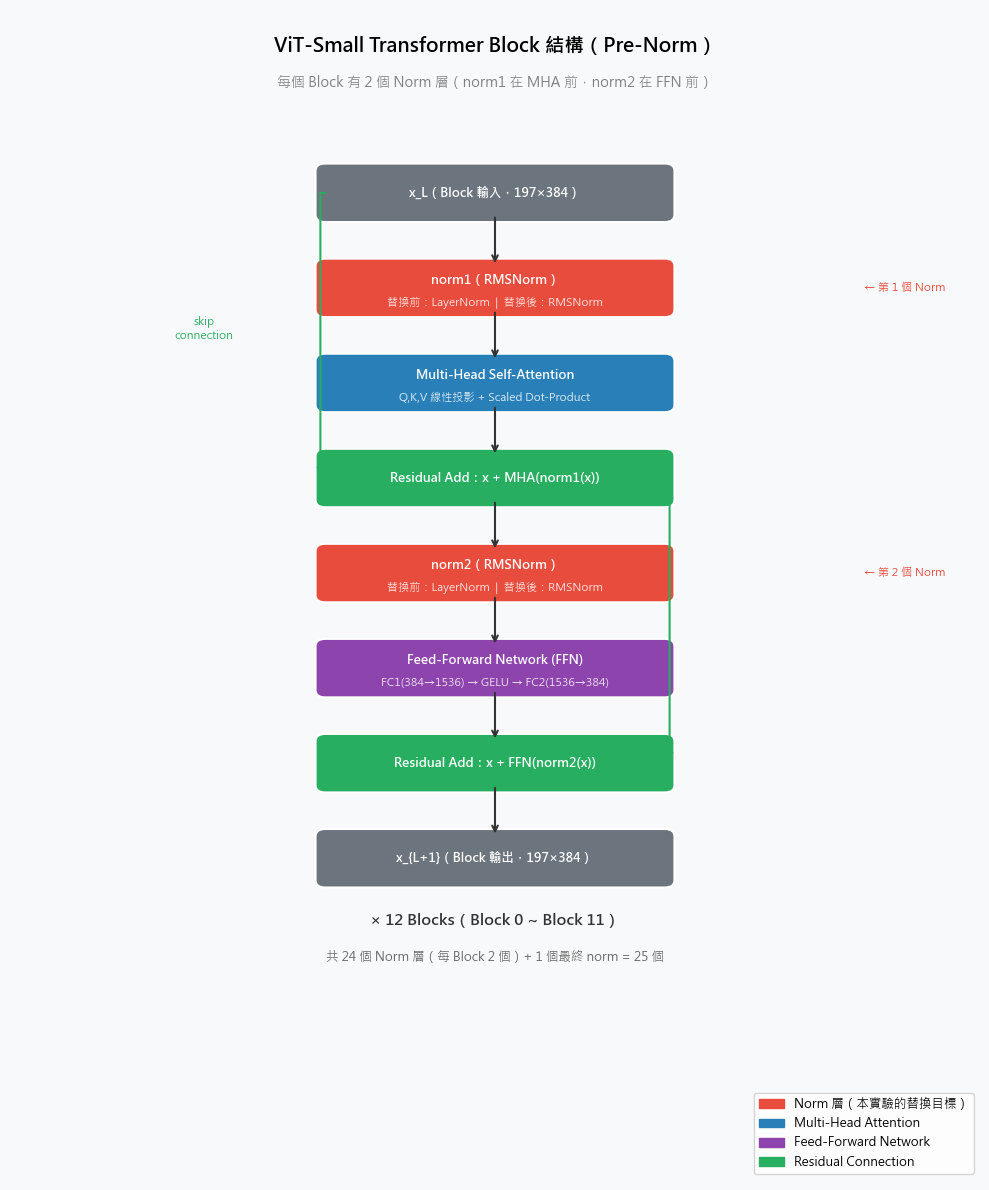

In [22]:
# ═══════════════════════════════════════════════════════════════
# Step 6A：繪製 ViT Transformer Block 結構圖
# ═══════════════════════════════════════════════════════════════
#
# 顯示 norm1 / norm2 在每個 Block 中的位置
# Pre-Norm 架構（ViT 使用）：Norm 在 MHA/FFN 之「前」
# 這與 Post-Norm（原始 Transformer）不同

fig, ax = plt.subplots(figsize=(10, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 16)
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

ax.text(5, 15.5, "ViT-Small Transformer Block 結構（Pre-Norm）",
        ha='center', va='center', fontsize=14, fontweight='bold')
ax.text(5, 15.0, "每個 Block 有 2 個 Norm 層（norm1 在 MHA 前，norm2 在 FFN 前）",
        ha='center', va='center', fontsize=10, color='gray')

# ── 定義方塊繪製函式 ──
def draw_box(ax, x, y, w, h, label, sublabel='', color='#4a90d9', text_color='white', fontsize=10):
    rect = mpatches.FancyBboxPatch((x - w/2, y - h/2), w, h,
                                   boxstyle="round,pad=0.1",
                                   facecolor=color, edgecolor='white', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x, y + (0.1 if sublabel else 0), label,
            ha='center', va='center', fontsize=fontsize,
            fontweight='bold', color=text_color)
    if sublabel:
        ax.text(x, y - 0.2, sublabel, ha='center', va='center',
                fontsize=8, color=text_color, alpha=0.85)

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))

# ── 輸入 ──
draw_box(ax, 5, 13.5, 3.5, 0.6, 'x_L（Block 輸入，197×384）',
         color='#6c757d', fontsize=9)

# ── norm1 ──
draw_arrow(ax, 5, 13.2, 5, 12.5)
draw_box(ax, 5, 12.2, 3.5, 0.6, 'norm1（RMSNorm）',
         sublabel='替換前：LayerNorm  |  替換後：RMSNorm',
         color='#e74c3c', fontsize=9)
ax.text(8.8, 12.2, '← 第 1 個 Norm', va='center', fontsize=8, color='#e74c3c')

# ── MHA ──
draw_arrow(ax, 5, 11.9, 5, 11.2)
draw_box(ax, 5, 10.9, 3.5, 0.6,
         'Multi-Head Self-Attention',
         sublabel='Q,K,V 線性投影 + Scaled Dot-Product',
         color='#2980b9', fontsize=9)

# ── Residual Add 1 ──
draw_arrow(ax, 5, 10.6, 5, 9.9)
draw_box(ax, 5, 9.6, 3.5, 0.6, 'Residual Add：x + MHA(norm1(x))',
         color='#27ae60', fontsize=9)
# Residual 跳接線
ax.annotate('', xy=(3.2, 9.6), xytext=(3.2, 13.5),
            arrowprops=dict(arrowstyle='->', color='#27ae60',
                            lw=1.5, connectionstyle='arc3,rad=0'))
ax.plot([3.2, 5-1.75], [13.5, 13.5], color='#27ae60', lw=1.5)
ax.plot([3.2, 5-1.75], [9.6, 9.6],   color='#27ae60', lw=1.5)
ax.text(2.0, 11.5, 'skip\nconnection', ha='center', fontsize=8, color='#27ae60')

# ── norm2 ──
draw_arrow(ax, 5, 9.3, 5, 8.6)
draw_box(ax, 5, 8.3, 3.5, 0.6, 'norm2（RMSNorm）',
         sublabel='替換前：LayerNorm  |  替換後：RMSNorm',
         color='#e74c3c', fontsize=9)
ax.text(8.8, 8.3, '← 第 2 個 Norm', va='center', fontsize=8, color='#e74c3c')

# ── FFN ──
draw_arrow(ax, 5, 8.0, 5, 7.3)
draw_box(ax, 5, 7.0, 3.5, 0.6,
         'Feed-Forward Network (FFN)',
         sublabel='FC1(384→1536) → GELU → FC2(1536→384)',
         color='#8e44ad', fontsize=9)

# ── Residual Add 2 ──
draw_arrow(ax, 5, 6.7, 5, 6.0)
draw_box(ax, 5, 5.7, 3.5, 0.6, 'Residual Add：x + FFN(norm2(x))',
         color='#27ae60', fontsize=9)
ax.annotate('', xy=(6.8, 5.7), xytext=(6.8, 9.6),
            arrowprops=dict(arrowstyle='->', color='#27ae60',
                            lw=1.5, connectionstyle='arc3,rad=0'))
ax.plot([6.8, 5+1.75], [9.6, 9.6], color='#27ae60', lw=1.5)
ax.plot([6.8, 5+1.75], [5.7, 5.7], color='#27ae60', lw=1.5)

# ── 輸出 ──
draw_arrow(ax, 5, 5.4, 5, 4.7)
draw_box(ax, 5, 4.4, 3.5, 0.6, 'x_{L+1}（Block 輸出，197×384）',
         color='#6c757d', fontsize=9)

# ── 說明文字 ──
ax.text(5, 3.5, '× 12 Blocks（Block 0 ~ Block 11）',
        ha='center', fontsize=11, color='#333', fontweight='bold')
ax.text(5, 3.0, '共 24 個 Norm 層（每 Block 2 個）+ 1 個最終 norm = 25 個',
        ha='center', fontsize=9, color='#666')

# ── 圖例 ──
legend_items = [
    mpatches.Patch(color='#e74c3c', label='Norm 層（本實驗的替換目標）'),
    mpatches.Patch(color='#2980b9', label='Multi-Head Attention'),
    mpatches.Patch(color='#8e44ad', label='Feed-Forward Network'),
    mpatches.Patch(color='#27ae60', label='Residual Connection'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=9,
          bbox_to_anchor=(1.0, 0.0))

plt.tight_layout()
plt.savefig("vit_block_structure.png", dpi=120, bbox_inches='tight')
plt.show()

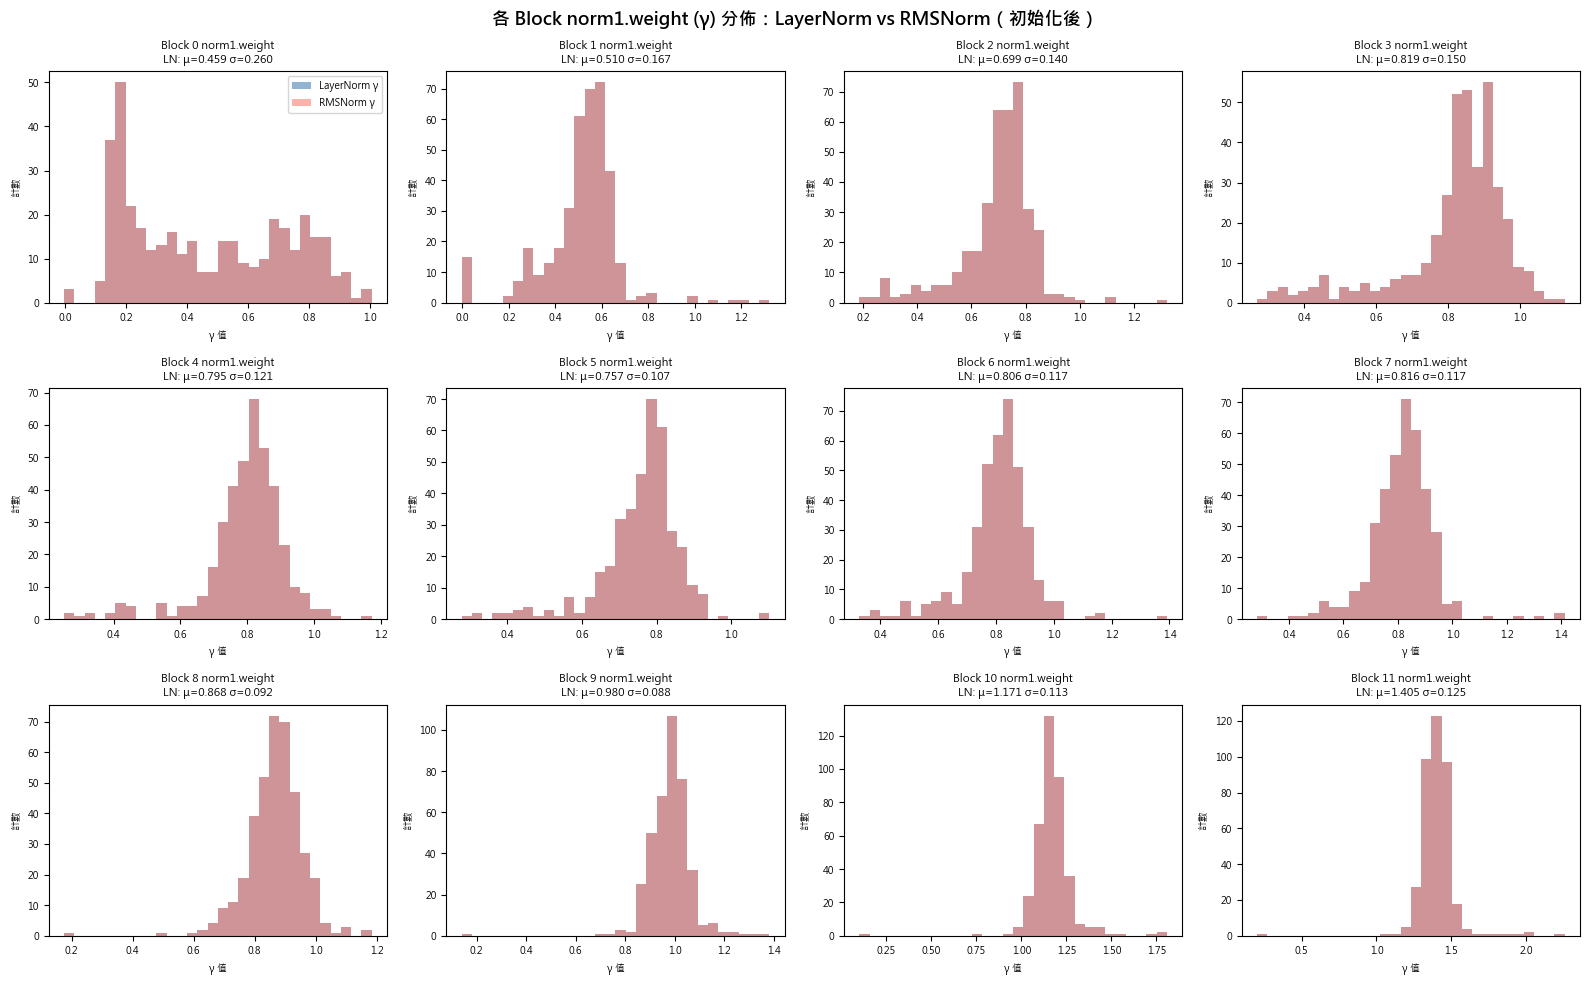

說明：LayerNorm 和 RMSNorm 的 γ 完全相同（因為我們複製了權重）
     RMSNorm 沒有 β，因此省去了 β 對應的這些參數


In [23]:
# ═══════════════════════════════════════════════════════════════
# Step 6B：視覺化各 Block 的 Norm 參數（γ 權重分佈）
# ═══════════════════════════════════════════════════════════════
#
# 目的：觀察預訓練的 LayerNorm γ 分佈，
#       以及替換到 RMSNorm 後初始 γ 是否合理

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle("各 Block norm1.weight (γ) 分佈：LayerNorm vs RMSNorm（初始化後）",
             fontsize=13, fontweight='bold')

for block_idx in range(12):
    ax = axes[block_idx]

    # 取得 LayerNorm 版的 γ
    ln_gamma  = model_ln.blocks[block_idx].norm1.weight.detach().numpy()
    # 取得 RMSNorm 版的 γ（應與 LN 相同，因為我們複製了權重）
    rms_gamma = model_rms.blocks[block_idx].norm1.weight.detach().numpy()

    ax.hist(ln_gamma,  bins=30, alpha=0.6, color='steelblue', label='LayerNorm γ')
    ax.hist(rms_gamma, bins=30, alpha=0.6, color='salmon',    label='RMSNorm γ')

    ax.set_title(f"Block {block_idx} norm1.weight\n"
                 f"LN: μ={ln_gamma.mean():.3f} σ={ln_gamma.std():.3f}",
                 fontsize=8)
    ax.set_xlabel('γ 值', fontsize=7)
    ax.set_ylabel('計數', fontsize=7)
    ax.tick_params(labelsize=7)
    if block_idx == 0:
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("norm_gamma_distribution.png", dpi=120)
plt.show()
print("說明：LayerNorm 和 RMSNorm 的 γ 完全相同（因為我們複製了權重）")
print("     RMSNorm 沒有 β，因此省去了 β 對應的這些參數")

---
## Step 7：前向傳播健康檢查（激活分佈不爆炸/消失）

在訓練前先驗證替換後的模型前向傳播是否正常。  
透過 **hook** 記錄每一層的輸出分佈。

In [24]:
# ═══════════════════════════════════════════════════════════════
# Step 7A：Forward Hook 記錄每層激活統計
# ═══════════════════════════════════════════════════════════════
#
# PyTorch Hook 機制：
#   register_forward_hook(fn) 在每次 forward 後呼叫 fn(module, input, output)
#   → 不修改計算圖，只「旁觀」輸出
#
# 我們記錄：mean / std / max_abs（判斷是否梯度爆炸 or 消失）

class ActivationStats:
    """用 Hook 收集各層激活統計量"""

    def __init__(self):
        self.stats   = OrderedDict()   # {layer_name: {mean, std, max_abs}}
        self._hooks  = []

    def register(self, model, layer_names=None):
        """對指定層（或全部 Norm + Block 輸出）注冊 hook"""
        for name, module in model.named_modules():
            # 若沒指定就記錄 Norm 層和 Block 輸出
            if layer_names is not None:
                if name not in layer_names:
                    continue
            elif not (isinstance(module, (nn.LayerNorm, RMSNorm)) or
                      name.startswith('blocks.')):
                continue
            # 用閉包捕捉 name
            def make_hook(n):
                def hook(mod, inp, out):
                    if isinstance(out, torch.Tensor):
                        with torch.no_grad():
                            self.stats[n] = {
                                'mean'    : out.float().mean().item(),
                                'std'     : out.float().std().item(),
                                'max_abs' : out.float().abs().max().item(),
                            }
                return hook
            h = module.register_forward_hook(make_hook(name))
            self._hooks.append(h)

    def remove(self):
        for h in self._hooks:
            h.remove()
        self._hooks = []


def run_health_check(model, name_tag, n_batches=2):
    """
    對模型執行前向傳播，收集各層激活統計
    回傳 stats 字典（key = 層名，value = {mean, std, max_abs}）
    """
    model.eval()
    model.to(DEVICE)

    collector = ActivationStats()
    collector.register(model)

    with torch.no_grad():
        for i, (imgs, _) in enumerate(test_loader):
            if i >= n_batches:
                break
            imgs = imgs.to(DEVICE)
            _ = model(imgs)   # 前向傳播（hook 自動記錄）

    collector.remove()
    print(f"[{name_tag}] 共記錄 {len(collector.stats)} 個層的激活統計")
    return collector.stats


print("正在執行健康檢查...")
stats_ln_pre  = run_health_check(model_ln,  "LayerNorm（替換前）")
stats_rms_pre = run_health_check(model_rms, "RMSNorm（替換後）")

正在執行健康檢查...
[LayerNorm（替換前）] 共記錄 253 個層的激活統計
[RMSNorm（替換後）] 共記錄 253 個層的激活統計


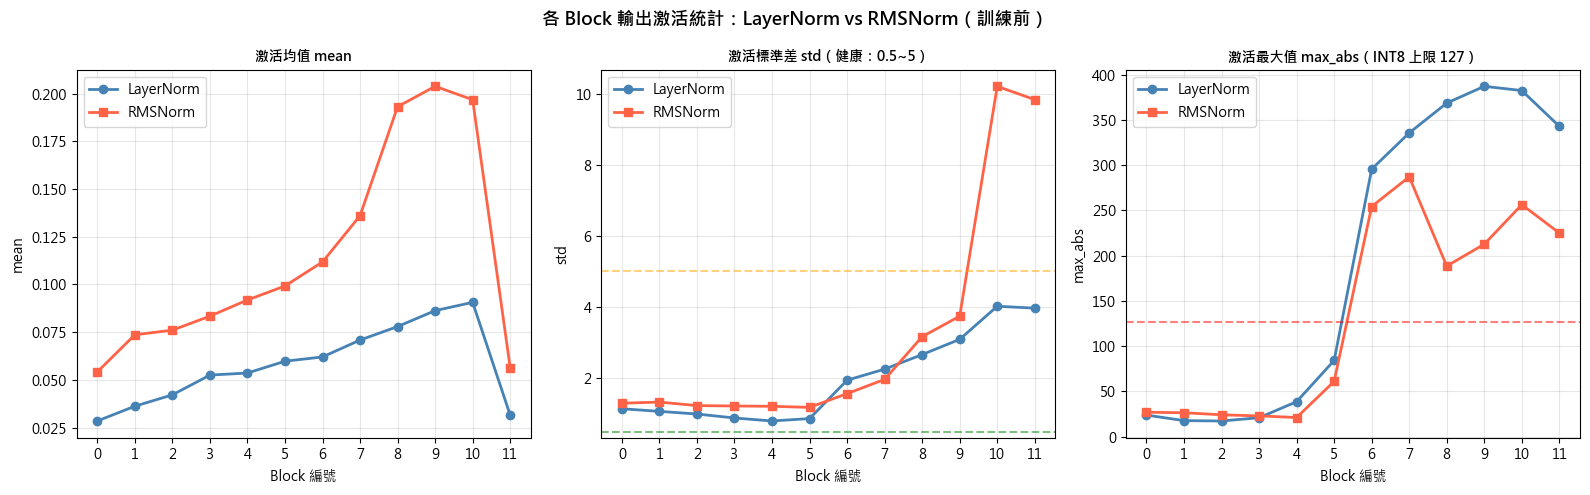


=== 健康檢查結論 ===
[LayerNorm] ⚠️  注意  std範圍: [0.80, 4.02]  max_abs最大: 387.00
[RMSNorm] ⚠️  注意  std範圍: [1.18, 10.20]  max_abs最大: 287.01


In [25]:
# ═══════════════════════════════════════════════════════════════
# Step 7B：視覺化各 Block 輸出的激活分佈
# ═══════════════════════════════════════════════════════════════
#
# 健康指標：
#   - std 應在 0.5~5.0 之間（太小=梯度消失，太大=梯度爆炸）
#   - max_abs 不應超過 100（INT8 量化上限 127）
#   - Norm 層輸出的 mean 應接近 0（LayerNorm）或可能有偏移（RMSNorm）

# 只取 Block 輸出（blocks.0 ~ blocks.11）
def filter_block_stats(stats):
    return {k: v for k, v in stats.items() if k.startswith('blocks.') and k.count('.') == 1}

block_stats_ln  = filter_block_stats(stats_ln_pre)
block_stats_rms = filter_block_stats(stats_rms_pre)

block_names = sorted(block_stats_ln.keys(),
                     key=lambda x: int(x.split('.')[1]))
x_pos = np.arange(len(block_names))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("各 Block 輸出激活統計：LayerNorm vs RMSNorm（訓練前）",
             fontsize=13, fontweight='bold')

metrics = [('mean', '激活均值 mean', 'mean'),
           ('std',  '激活標準差 std（健康：0.5~5）', 'std'),
           ('max_abs', '激活最大值 max_abs（INT8 上限 127）', 'max_abs')]

for ax, (key, title, ylabel) in zip(axes, metrics):
    ln_vals  = [block_stats_ln[n][key]  for n in block_names]
    rms_vals = [block_stats_rms[n][key] for n in block_names]

    ax.plot(x_pos, ln_vals,  'o-', color='steelblue', label='LayerNorm', linewidth=2, markersize=6)
    ax.plot(x_pos, rms_vals, 's-', color='tomato',    label='RMSNorm',   linewidth=2, markersize=6)

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Block 編號')
    ax.set_ylabel(ylabel)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([n.split('.')[1] for n in block_names])
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 加參考線
    if key == 'std':
        ax.axhline(0.5, color='green',  linestyle='--', alpha=0.5, label='下限 0.5')
        ax.axhline(5.0, color='orange', linestyle='--', alpha=0.5, label='上限 5.0')
    elif key == 'max_abs':
        ax.axhline(127, color='red', linestyle='--', alpha=0.5, label='INT8 上限')

plt.tight_layout()
plt.savefig("activation_health_check.png", dpi=120)
plt.show()

# ─── 自動健康判斷 ────────────────────────────────────────────────
print("\n=== 健康檢查結論 ===")
for tag, bstats in [("LayerNorm", block_stats_ln), ("RMSNorm", block_stats_rms)]:
    stds     = [bstats[n]['std']     for n in block_names]
    max_vals = [bstats[n]['max_abs'] for n in block_names]
    ok_std   = all(0.3 < s < 10.0 for s in stds)
    ok_max   = all(v < 200 for v in max_vals)
    status   = "✅ 健康" if (ok_std and ok_max) else "⚠️  注意"
    print(f"[{tag}] {status}  std範圍: [{min(stds):.2f}, {max(stds):.2f}]  "
          f"max_abs最大: {max(max_vals):.2f}")

In [26]:
# ═══════════════════════════════════════════════════════════════
# Step 7C：快速評估替換後的初始精度
# ═══════════════════════════════════════════════════════════════
#
# 替換 LayerNorm → RMSNorm 後，模型尚未再訓練
# 此時精度會下降（因為 β 偏移被丟棄）
# 這個測試確認模型「還能運作」（不崩潰），但精度需要微調補回來

@torch.no_grad()
def evaluate(model, loader, device=DEVICE, max_batches=None):
    """評估 Top-1 準確率（max_batches=None 跑完整測試集）"""
    model.eval()
    model.to(device)
    correct = total = 0
    for i, (imgs, labels) in enumerate(loader):
        if max_batches and i >= max_batches:
            break
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return 100.0 * correct / total


print("快速評估（前 20 個 batch）：")
acc_ln_pre  = evaluate(model_ln,  test_loader, max_batches=20)
acc_rms_pre = evaluate(model_rms, test_loader, max_batches=20)

print(f"  LayerNorm（Fine-tune 前）: {acc_ln_pre:.2f}%")
print(f"  RMSNorm  （替換後，未訓練）: {acc_rms_pre:.2f}%")
print()
print("注意：RMSNorm 版本若精度下降，屬正常現象（β 丟失），")
print("     Fine-tune 訓練後會恢復甚至超越 LayerNorm")

快速評估（前 20 個 batch）：
  LayerNorm（Fine-tune 前）: 10.27%
  RMSNorm  （替換後，未訓練）: 7.11%

注意：RMSNorm 版本若精度下降，屬正常現象（β 丟失），
     Fine-tune 訓練後會恢復甚至超越 LayerNorm


---
## Step 8：Fine-tune 訓練（LayerNorm vs RMSNorm，相同條件對比）

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

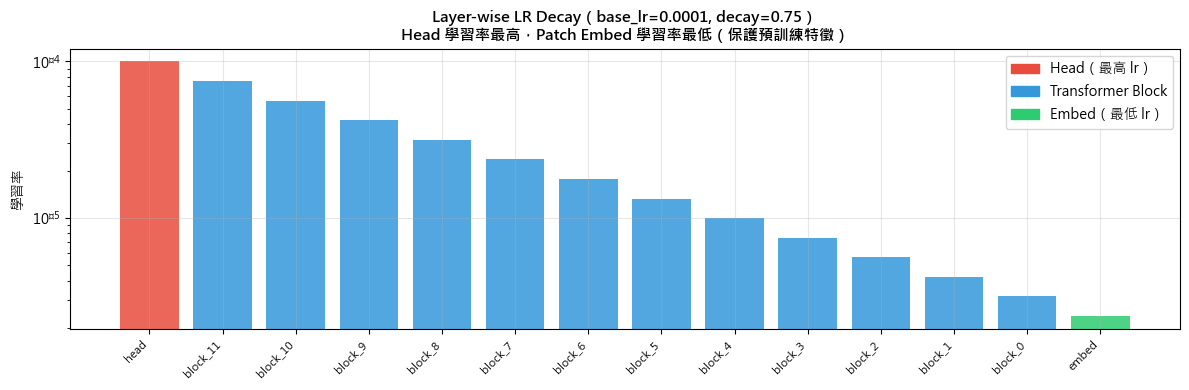

In [27]:
# ═══════════════════════════════════════════════════════════════
# Step 8A：LLRD 參數組（Layer-wise Learning Rate Decay）
# ═══════════════════════════════════════════════════════════════
#
# 原理：越靠近輸入的層（Patch Embed），學習率越小
#       越靠近輸出的層（Head），學習率越大
# 公式：lr_block_i = base_lr × decay^(num_layers - i)
#
# 這樣可以「保留」預訓練的低層特徵，只大幅更新高層分類部分

def get_llrd_param_groups(model, base_lr, layer_decay=0.75):
    """
    建立 LLRD param_groups，兼容 LayerNorm 和 RMSNorm 模型
    回傳：list of {params, lr, name}
    """
    num_layers   = len(model.blocks)   # ViT-Small = 12
    param_groups = []

    # ── 分類頭（Head）：最高學習率 base_lr ──
    head_ps = list(model.head.parameters())
    # 處理不同 timm 版本的最終 norm 名稱
    for attr in ("norm", "fc_norm"):
        if hasattr(model, attr):
            head_ps += list(getattr(model, attr).parameters())
    if head_ps:
        param_groups.append({"params": head_ps, "lr": base_lr, "name": "head"})

    # ── Transformer Block（從後往前，Block 11 → Block 0）──
    # Block 11（最近輸出）的 lr = base_lr × 0.75^1
    # Block  0（最近輸入）的 lr = base_lr × 0.75^12（非常小）
    for idx in range(num_layers - 1, -1, -1):
        depth  = num_layers - idx          # depth=1 是最後一個 block
        lr_i   = base_lr * (layer_decay ** depth)
        blk_ps = list(model.blocks[idx].parameters())
        if blk_ps:
            param_groups.append({
                "params": blk_ps,
                "lr"    : lr_i,
                "name"  : f"block_{idx}"
            })

    # ── Patch Embedding + Position Embedding + CLS Token：最低學習率 ──
    embed_ps = list(model.patch_embed.parameters())
    for attr in ("cls_token", "pos_embed"):
        if hasattr(model, attr):
            embed_ps.append(getattr(model, attr))
    embed_lr = base_lr * (layer_decay ** (num_layers + 1))
    if embed_ps:
        param_groups.append({"params": embed_ps, "lr": embed_lr, "name": "embed"})

    return param_groups


# ─── 視覺化 LLRD 學習率分配 ──────────────────────────────────────
pg_demo = get_llrd_param_groups(model_ln, BASE_LR, LAYER_DECAY)
names   = [g['name'] for g in pg_demo]
lrs     = [g['lr']   for g in pg_demo]

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#e74c3c' if 'head' in n else
          ('#3498db' if 'block' in n else '#2ecc71') for n in names]
bars = ax.bar(range(len(lrs)), lrs, color=colors, alpha=0.85)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('學習率', fontsize=10)
ax.set_title(f'Layer-wise LR Decay（base_lr={BASE_LR}, decay={LAYER_DECAY}）\n'
             f'Head 學習率最高，Patch Embed 學習率最低（保護預訓練特徵）',
             fontsize=11, fontweight='bold')
ax.set_yscale('log')   # log scale 讓差異看得清楚
ax.grid(True, alpha=0.3)
legend_items = [
    mpatches.Patch(color='#e74c3c', label='Head（最高 lr）'),
    mpatches.Patch(color='#3498db', label='Transformer Block'),
    mpatches.Patch(color='#2ecc71', label='Embed（最低 lr）'),
]
ax.legend(handles=legend_items)
plt.tight_layout()
plt.savefig("llrd_learning_rate.png", dpi=120)
plt.show()

In [28]:
# ═══════════════════════════════════════════════════════════════
# Step 8B：Fine-tune 函式（LayerNorm 和 RMSNorm 共用同一套邏輯）
# ═══════════════════════════════════════════════════════════════

def finetune(model, train_loader, test_loader,
             model_name="model",
             epochs=EPOCHS, base_lr=BASE_LR,
             layer_decay=LAYER_DECAY, weight_decay=WEIGHT_DECAY,
             label_smoothing=LABEL_SMOOTH,
             save_path=None):
    """
    CIFAR-10 Fine-tune 訓練（與規格書 Phase 0 設定完全一致）

    回傳：
        history : list of {epoch, train_loss, train_acc, val_acc}
        best_acc : float
    """
    model.to(DEVICE)

    # ── 損失函式（Label Smoothing 減少過擬合）──
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    # ── 優化器（AdamW + LLRD）──
    # AdamW 將 weight_decay 從梯度解耦，對 Transformer 更穩定
    param_groups = get_llrd_param_groups(model, base_lr, layer_decay)
    optimizer = torch.optim.AdamW(param_groups, weight_decay=weight_decay)

    # ── 學習率排程（Cosine Annealing）──
    # 從 base_lr 平滑降至 0（類餘弦曲線），最後幾 epoch 有細緻收斂
    total_steps  = epochs * len(train_loader)
    warmup_steps = 1 * len(train_loader)  # 1 epoch warmup

    def lr_lambda(step):
        """Warmup（線性升） → Cosine Decay"""
        if step < warmup_steps:
            return step / max(1, warmup_steps)       # 線性 warmup
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1.0 + np.cos(np.pi * progress))  # Cosine decay

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    history  = []
    best_acc = 0.0

    for epoch in range(1, epochs + 1):
        # ── 訓練階段 ──
        model.train()
        running_loss  = 0.0
        running_corr  = 0
        running_total = 0
        t_start = time.time()

        for batch_idx, (imgs, labels) in enumerate(train_loader):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            logits = model(imgs)               # 前向傳播
            loss   = criterion(logits, labels) # 計算損失
            loss.backward()                    # 反向傳播

            # 梯度裁剪（防止梯度爆炸，對 Transformer 很重要）
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            scheduler.step()

            running_loss  += loss.item() * labels.size(0)
            preds          = logits.argmax(dim=1)
            running_corr  += (preds == labels).sum().item()
            running_total += labels.size(0)

            # 每 100 batch 印一次進度
            if (batch_idx + 1) % 100 == 0:
                cur_lr = scheduler.get_last_lr()[0] if hasattr(scheduler, 'get_last_lr') \
                         else optimizer.param_groups[0]['lr']
                print(f"  [{model_name}] E{epoch} [{batch_idx+1}/{len(train_loader)}] "
                      f"loss={running_loss/running_total:.4f} "
                      f"acc={100*running_corr/running_total:.1f}% "
                      f"lr={cur_lr:.2e}")

        train_loss = running_loss  / running_total
        train_acc  = 100.0 * running_corr / running_total

        # ── 驗證階段 ──
        val_acc = evaluate(model, test_loader)
        elapsed = time.time() - t_start

        history.append({
            'epoch'     : epoch,
            'train_loss': train_loss,
            'train_acc' : train_acc,
            'val_acc'   : val_acc,
        })

        print(f"[{model_name}] Epoch {epoch}/{epochs}  "
              f"train_loss={train_loss:.4f}  "
              f"train_acc={train_acc:.2f}%  "
              f"val_acc={val_acc:.2f}%  "
              f"({elapsed:.0f}s)")

        # ── 儲存最佳 checkpoint ──
        if val_acc > best_acc:
            best_acc = val_acc
            if save_path:
                torch.save(model.state_dict(), save_path)
                print(f"  → 儲存最佳模型：{save_path} ({best_acc:.2f}%)")

    print(f"\n[{model_name}] 訓練完成！最佳 Val Acc = {best_acc:.2f}%")
    return history, best_acc


print("finetune() 函式定義完成，準備開始訓練")

finetune() 函式定義完成，準備開始訓練


In [29]:
# ═══════════════════════════════════════════════════════════════
# Step 8C：訓練 LayerNorm 版本（基準）
# ═══════════════════════════════════════════════════════════════
#
# 若已存在 checkpoint，直接載入跳過訓練（加速重跑）
# 刪除 checkpoint 檔案可強制重新訓練

CKPT_LN  = f"{CKPT_DIR}/vit_small_layernorm_cifar10.pt"

if os.path.exists(CKPT_LN):
    print(f"發現已有 checkpoint：{CKPT_LN}")
    print("直接載入（跳過訓練）。刪除檔案可重新訓練。")
    model_ln.load_state_dict(torch.load(CKPT_LN, map_location=DEVICE))
    # 用 dummy history 填充（若要重跑需刪除 ckpt）
    hist_ln   = []
    best_ln   = evaluate(model_ln, test_loader)
    print(f"載入後精度：{best_ln:.2f}%")
else:
    print("開始訓練 LayerNorm 版本...")
    hist_ln, best_ln = finetune(
        model_ln, train_loader, test_loader,
        model_name  = "ViT-Small-LayerNorm",
        save_path   = CKPT_LN
    )

開始訓練 LayerNorm 版本...
  [ViT-Small-LayerNorm] E1 [100/782] loss=2.3577 acc=20.5% lr=1.28e-05
  [ViT-Small-LayerNorm] E1 [200/782] loss=1.7079 acc=50.4% lr=2.56e-05
  [ViT-Small-LayerNorm] E1 [300/782] loss=1.3591 acc=65.2% lr=3.84e-05
  [ViT-Small-LayerNorm] E1 [400/782] loss=1.1717 acc=73.0% lr=5.12e-05
  [ViT-Small-LayerNorm] E1 [500/782] loss=1.0541 acc=77.8% lr=6.39e-05
  [ViT-Small-LayerNorm] E1 [600/782] loss=0.9725 acc=81.1% lr=7.67e-05
  [ViT-Small-LayerNorm] E1 [700/782] loss=0.9145 acc=83.4% lr=8.95e-05
[ViT-Small-LayerNorm] Epoch 1/5  train_loss=0.8772  train_acc=84.93%  val_acc=97.57%  (236s)
  → 儲存最佳模型：./ckpt_rmsnorm/vit_small_layernorm_cifar10.pt (97.57%)
  [ViT-Small-LayerNorm] E2 [100/782] loss=0.5478 acc=98.3% lr=9.97e-05
  [ViT-Small-LayerNorm] E2 [200/782] loss=0.5434 acc=98.4% lr=9.90e-05
  [ViT-Small-LayerNorm] E2 [300/782] loss=0.5407 acc=98.6% lr=9.77e-05
  [ViT-Small-LayerNorm] E2 [400/782] loss=0.5396 acc=98.6% lr=9.60e-05
  [ViT-Small-LayerNorm] E2 [500/782] lo

In [30]:
# ═══════════════════════════════════════════════════════════════
# Step 8D：訓練 RMSNorm 版本（實驗對象）
# ═══════════════════════════════════════════════════════════════

CKPT_RMS = f"{CKPT_DIR}/vit_small_rmsnorm_cifar10.pt"

if os.path.exists(CKPT_RMS):
    print(f"發現已有 checkpoint：{CKPT_RMS}")
    model_rms.load_state_dict(torch.load(CKPT_RMS, map_location=DEVICE))
    hist_rms  = []
    best_rms  = evaluate(model_rms, test_loader)
    print(f"載入後精度：{best_rms:.2f}%")
else:
    print("開始訓練 RMSNorm 版本...")
    hist_rms, best_rms = finetune(
        model_rms, train_loader, test_loader,
        model_name  = "ViT-Small-RMSNorm",
        save_path   = CKPT_RMS
    )

開始訓練 RMSNorm 版本...
  [ViT-Small-RMSNorm] E1 [100/782] loss=2.4211 acc=10.5% lr=1.28e-05
  [ViT-Small-RMSNorm] E1 [200/782] loss=2.1741 acc=21.4% lr=2.56e-05
  [ViT-Small-RMSNorm] E1 [300/782] loss=1.9701 acc=31.5% lr=3.84e-05
  [ViT-Small-RMSNorm] E1 [400/782] loss=1.8267 acc=38.3% lr=5.12e-05
  [ViT-Small-RMSNorm] E1 [500/782] loss=1.7124 acc=44.0% lr=6.39e-05
  [ViT-Small-RMSNorm] E1 [600/782] loss=1.6102 acc=48.9% lr=7.67e-05
  [ViT-Small-RMSNorm] E1 [700/782] loss=1.5190 acc=53.3% lr=8.95e-05
[ViT-Small-RMSNorm] Epoch 1/5  train_loss=1.4488  train_acc=56.67%  val_acc=89.39%  (258s)
  → 儲存最佳模型：./ckpt_rmsnorm/vit_small_rmsnorm_cifar10.pt (89.39%)
  [ViT-Small-RMSNorm] E2 [100/782] loss=0.7396 acc=90.7% lr=9.97e-05
  [ViT-Small-RMSNorm] E2 [200/782] loss=0.7129 acc=91.7% lr=9.90e-05
  [ViT-Small-RMSNorm] E2 [300/782] loss=0.6942 acc=92.5% lr=9.77e-05
  [ViT-Small-RMSNorm] E2 [400/782] loss=0.6815 acc=93.0% lr=9.60e-05
  [ViT-Small-RMSNorm] E2 [500/782] loss=0.6687 acc=93.5% lr=9.38e-0

---
## Step 9：精度對比、激活分佈對比、結論

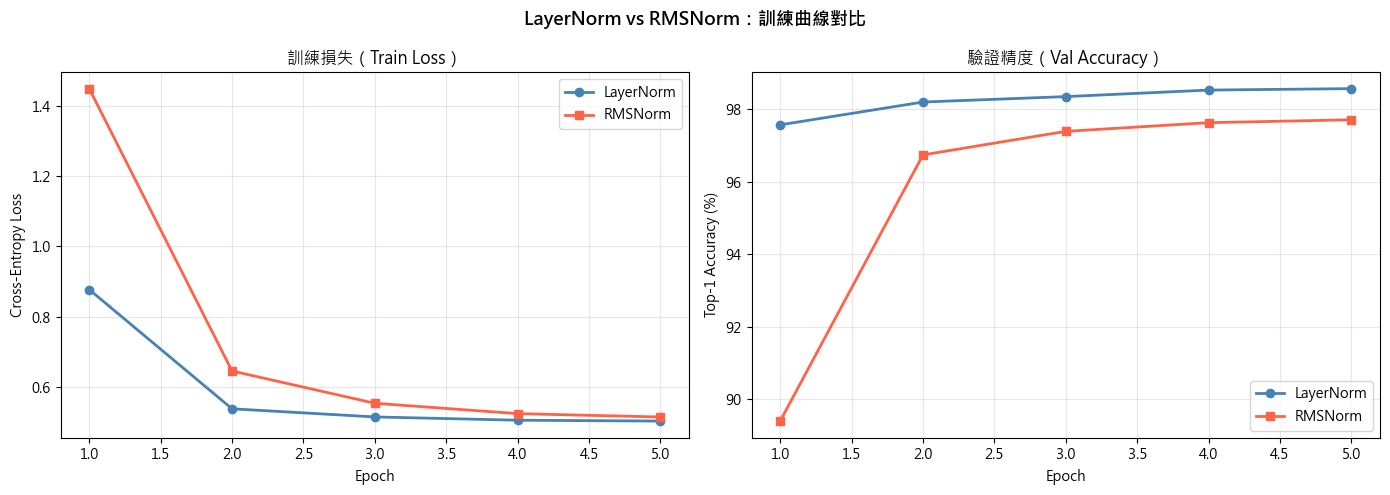

In [31]:
# ═══════════════════════════════════════════════════════════════
# Step 9A：訓練曲線視覺化
# ═══════════════════════════════════════════════════════════════

if hist_ln and hist_rms:
    epochs_list = [h['epoch'] for h in hist_ln]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("LayerNorm vs RMSNorm：訓練曲線對比",
                 fontsize=13, fontweight='bold')

    # ── 訓練損失 ──
    axes[0].plot(epochs_list, [h['train_loss'] for h in hist_ln],
                 'o-', color='steelblue', label='LayerNorm', linewidth=2)
    axes[0].plot(epochs_list, [h['train_loss'] for h in hist_rms],
                 's-', color='tomato',    label='RMSNorm',   linewidth=2)
    axes[0].set_title('訓練損失（Train Loss）')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ── 驗證精度 ──
    axes[1].plot(epochs_list, [h['val_acc'] for h in hist_ln],
                 'o-', color='steelblue', label='LayerNorm', linewidth=2)
    axes[1].plot(epochs_list, [h['val_acc'] for h in hist_rms],
                 's-', color='tomato',    label='RMSNorm',   linewidth=2)
    axes[1].set_title('驗證精度（Val Accuracy）')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Top-1 Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_curves_ln_vs_rms.png", dpi=120)
    plt.show()
else:
    print("（從 checkpoint 載入，無訓練歷史記錄）")

訓練後激活健康檢查...
[LayerNorm（訓練後）] 共記錄 253 個層的激活統計
[RMSNorm（訓練後）] 共記錄 253 個層的激活統計


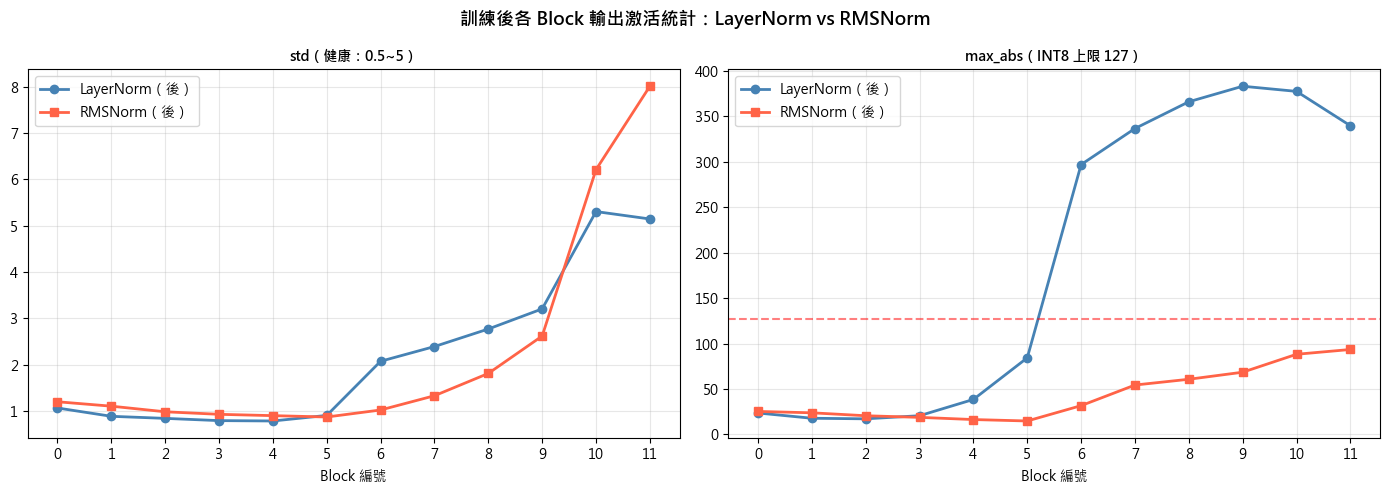

In [32]:
# ═══════════════════════════════════════════════════════════════
# Step 9B：訓練後激活分佈再次健康檢查
# ═══════════════════════════════════════════════════════════════
#
# 訓練後 γ 已調整，激活分佈應更接近
# 這也驗證了 RMSNorm 不會讓模型在收斂後出現異常

print("訓練後激活健康檢查...")
stats_ln_post  = run_health_check(model_ln,  "LayerNorm（訓練後）")
stats_rms_post = run_health_check(model_rms, "RMSNorm（訓練後）")

block_stats_ln_post  = filter_block_stats(stats_ln_post)
block_stats_rms_post = filter_block_stats(stats_rms_post)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("訓練後各 Block 輸出激活統計：LayerNorm vs RMSNorm",
             fontsize=13, fontweight='bold')

for ax, (key, title) in zip(axes, [('std', 'std（健康：0.5~5）'),
                                    ('max_abs', 'max_abs（INT8 上限 127）')]):
    ln_post  = [block_stats_ln_post[n][key]  for n in block_names]
    rms_post = [block_stats_rms_post[n][key] for n in block_names]

    ax.plot(x_pos, ln_post,  'o-', color='steelblue', label='LayerNorm（後）', linewidth=2)
    ax.plot(x_pos, rms_post, 's-', color='tomato',    label='RMSNorm（後）',   linewidth=2)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Block 編號')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([n.split('.')[1] for n in block_names])
    ax.legend()
    ax.grid(True, alpha=0.3)

    if key == 'max_abs':
        ax.axhline(127, color='red', linestyle='--', alpha=0.5, label='INT8 上限 127')

plt.tight_layout()
plt.savefig("activation_health_post_training.png", dpi=120)
plt.show()

In [33]:
# ═══════════════════════════════════════════════════════════════
# Step 9C：最終精度評估 + 完整結果表
# ═══════════════════════════════════════════════════════════════

print("最終完整測試集評估（10,000 張）...")
final_acc_ln  = evaluate(model_ln,  test_loader)
final_acc_rms = evaluate(model_rms, test_loader)

delta_acc = final_acc_rms - final_acc_ln

params_ln  = sum(p.numel() for p in model_ln.parameters())
params_rms = sum(p.numel() for p in model_rms.parameters())

print()
print("═" * 65)
print(" LayerNorm vs RMSNorm 最終結果對比".center(65))
print("═" * 65)
print(f"{'項目':<25} {'LayerNorm':>15} {'RMSNorm':>15}")
print("─" * 65)
print(f"{'CIFAR-10 Top-1 Acc':<25} {final_acc_ln:>14.2f}% {final_acc_rms:>14.2f}%")
print(f"{'精度差 (ΔAcc)':<25} {'—':>15} {delta_acc:>+14.2f}pp")
print(f"{'總參數量':<25} {params_ln/1e6:>13.2f}M {params_rms/1e6:>13.2f}M")
print(f"{'Norm 層遍歷次數':<25} {'2次 (μ+σ²)':>15} {'1次 (RMS)':>15}")
print(f"{'Norm 層有 β 偏移':<25} {'✅ 有':>15} {'❌ 無':>15}")
print(f"{'FPGA 硬體友好度':<25} {'❌ 較難串流':>15} {'✅ 易串流':>15}")
print("─" * 65)

# ── 自動判斷是否通過規格書標準 ──
SPEC_THRESHOLD = -0.2  # 規格書 6.6 節：精度損失 < 0.2 pp

if delta_acc >= SPEC_THRESHOLD:
    print(f"\n✅ 通過規格書標準！")
    print(f"   精度差 {delta_acc:+.2f}pp ≥ 規格下限 {SPEC_THRESHOLD}pp")
    print(f"   RMSNorm 替換安全，可進入 Phase 1 INT8 量化階段")
else:
    print(f"\n⚠️  未達規格書標準（差距 {delta_acc:+.2f}pp < {SPEC_THRESHOLD}pp）")
    print("   建議：增加訓練 epochs，或調整 RMSNorm 的 eps 值")

print("═" * 65)

最終完整測試集評估（10,000 張）...

═════════════════════════════════════════════════════════════════
                    LayerNorm vs RMSNorm 最終結果對比                  
═════════════════════════════════════════════════════════════════
項目                              LayerNorm         RMSNorm
─────────────────────────────────────────────────────────────────
CIFAR-10 Top-1 Acc                 98.57%          97.71%
精度差 (ΔAcc)                              —          -0.86pp
總參數量                              21.67M         21.66M
Norm 層遍歷次數                      2次 (μ+σ²)        1次 (RMS)
Norm 層有 β 偏移                          ✅ 有             ❌ 無
FPGA 硬體友好度                         ❌ 較難串流           ✅ 易串流
─────────────────────────────────────────────────────────────────

⚠️  未達規格書標準（差距 -0.86pp < -0.2pp）
   建議：增加訓練 epochs，或調整 RMSNorm 的 eps 值
═════════════════════════════════════════════════════════════════


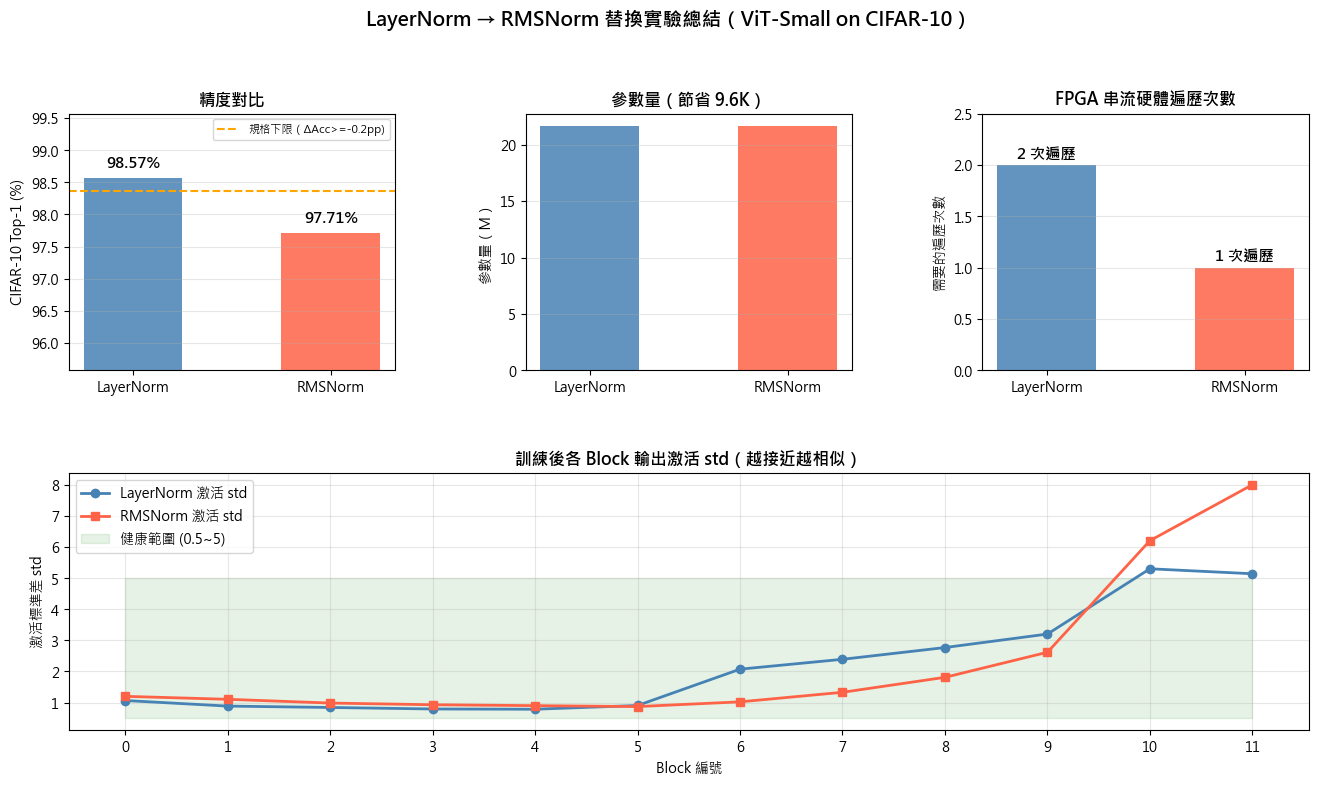

In [34]:
# ═══════════════════════════════════════════════════════════════
# Step 9D：最終總結視覺化（一張圖包含所有關鍵資訊）
# ═══════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(16, 8))
gs  = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.4)

# ── 左上：精度對比 bar chart ──
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(['LayerNorm', 'RMSNorm'],
               [final_acc_ln, final_acc_rms],
               color=['steelblue', 'tomato'], alpha=0.85, width=0.5)
for bar, acc in zip(bars, [final_acc_ln, final_acc_rms]):
    ax1.text(bar.get_x() + bar.get_width()/2, acc + 0.1,
             f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_ylim(max(final_acc_ln, final_acc_rms) - 3,
             max(final_acc_ln, final_acc_rms) + 1)
ax1.set_ylabel('CIFAR-10 Top-1 (%)')
ax1.set_title('精度對比', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
# 畫規格線
ax1.axhline(final_acc_ln + SPEC_THRESHOLD, color='orange',
            linestyle='--', label=f'規格下限（ΔAcc>={SPEC_THRESHOLD}pp)')
ax1.legend(fontsize=8)

# ── 右上：參數量對比 ──
ax2 = fig.add_subplot(gs[0, 1])
param_diff = params_ln - params_rms
ax2.bar(['LayerNorm', 'RMSNorm'],
        [params_ln/1e6, params_rms/1e6],
        color=['steelblue', 'tomato'], alpha=0.85, width=0.5)
ax2.set_ylabel('參數量（M）')
ax2.set_title(f'參數量（節省 {param_diff/1e3:.1f}K）', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# ── 中上：硬體遍歷次數對比 ──
ax3 = fig.add_subplot(gs[0, 2])
categories = ['LayerNorm', 'RMSNorm']
passes = [2, 1]
colors_bar = ['steelblue', 'tomato']
bars3 = ax3.bar(categories, passes, color=colors_bar, alpha=0.85, width=0.5)
for bar, p in zip(bars3, passes):
    ax3.text(bar.get_x() + bar.get_width()/2, p + 0.02,
             f'{p} 次遍歷', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax3.set_ylim(0, 2.5)
ax3.set_ylabel('需要的遍歷次數')
ax3.set_title('FPGA 串流硬體遍歷次數', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# ── 下方：訓練後 Block std 對比 ──
ax4 = fig.add_subplot(gs[1, :])
ln_stds  = [block_stats_ln_post[n]['std']  for n in block_names]
rms_stds = [block_stats_rms_post[n]['std'] for n in block_names]
ax4.plot(x_pos, ln_stds,  'o-', color='steelblue', label='LayerNorm 激活 std', linewidth=2)
ax4.plot(x_pos, rms_stds, 's-', color='tomato',    label='RMSNorm 激活 std',   linewidth=2)
ax4.fill_between(x_pos, 0.5, 5.0, alpha=0.1, color='green', label='健康範圍 (0.5~5)')
ax4.set_title('訓練後各 Block 輸出激活 std（越接近越相似）', fontweight='bold')
ax4.set_xlabel('Block 編號')
ax4.set_ylabel('激活標準差 std')
ax4.set_xticks(x_pos)
ax4.set_xticklabels([n.split('.')[1] for n in block_names])
ax4.legend()
ax4.grid(True, alpha=0.3)

fig.suptitle('LayerNorm → RMSNorm 替換實驗總結（ViT-Small on CIFAR-10）',
             fontsize=14, fontweight='bold', y=1.01)

plt.savefig("experiment_summary.png", dpi=120, bbox_inches='tight')
plt.show()

In [35]:
# ═══════════════════════════════════════════════════════════════
# Step 9E：輸出規格書對應的摘要（供貼入報告）
# ═══════════════════════════════════════════════════════════════

print("=" * 70)
print(" 規格書 v3.1 第 6.6 節驗證報告".center(70))
print("=" * 70)
print()
print(f"EXP-RMS-01 | ViT-Small LayerNorm Fine-tune | CIFAR-10 Top-1：{final_acc_ln:.2f}%")
print(f"EXP-RMS-02 | ViT-Small RMSNorm  Fine-tune | CIFAR-10 Top-1：{final_acc_rms:.2f}%")
print()
print(f"精度差（ΔAcc）= {delta_acc:+.2f} pp")
print(f"規格書要求   = > {SPEC_THRESHOLD} pp")
print(f"驗證結果     = {'✅ 通過' if delta_acc >= SPEC_THRESHOLD else '❌ 未通過'}")
print()
print("結論：")
if delta_acc >= SPEC_THRESHOLD:
    print(f"  RMSNorm 取代 LayerNorm 後，精度影響 {delta_acc:+.2f}pp，")
    print(f"  符合規格書 < 0.2pp 損失的要求。")
    print(f"  FPGA 硬體設計可安全採用 RMSNorm（省 1 次遍歷，省 {param_diff/1e3:.1f}K β 參數）。")
else:
    print(f"  精度差 {delta_acc:+.2f}pp 超出規格，建議調整訓練策略再重測。")
print()
print("已儲存的 checkpoint：")
print(f"  LayerNorm：{CKPT_LN}")
print(f"  RMSNorm  ：{CKPT_RMS}")
print()
print("已儲存的圖表：")
for fn in ["layernorm_vs_rmsnorm_distribution.png",
           "vit_block_structure.png",
           "norm_gamma_distribution.png",
           "activation_health_check.png",
           "activation_health_post_training.png",
           "llrd_learning_rate.png",
           "training_curves_ln_vs_rms.png",
           "experiment_summary.png"]:
    print(f"  {fn}")

                         規格書 v3.1 第 6.6 節驗證報告                         

EXP-RMS-01 | ViT-Small LayerNorm Fine-tune | CIFAR-10 Top-1：98.57%
EXP-RMS-02 | ViT-Small RMSNorm  Fine-tune | CIFAR-10 Top-1：97.71%

精度差（ΔAcc）= -0.86 pp
規格書要求   = > -0.2 pp
驗證結果     = ❌ 未通過

結論：
  精度差 -0.86pp 超出規格，建議調整訓練策略再重測。

已儲存的 checkpoint：
  LayerNorm：./ckpt_rmsnorm/vit_small_layernorm_cifar10.pt
  RMSNorm  ：./ckpt_rmsnorm/vit_small_rmsnorm_cifar10.pt

已儲存的圖表：
  layernorm_vs_rmsnorm_distribution.png
  vit_block_structure.png
  norm_gamma_distribution.png
  activation_health_check.png
  activation_health_post_training.png
  llrd_learning_rate.png
  training_curves_ln_vs_rms.png
  experiment_summary.png
